# AI-Driven Fraud Detection: Logistic Regression on Card Transactions

## Objective

This notebook documents the Day 5 **AI-Driven Fraud Detection** workstream of the
*Enterprise Risk, Credit Risk, Liquidity Risk, and Fraud Analytics for Canadian Payments* project.

The goal is to:

- Extend the rules-based fraud module with an **AI model** that assigns a fraud risk score to each transaction.
- Use a **logistic regression** model trained on transaction features and rules-based flags.
- Evaluate model performance with standard fraud metrics.
- Integrate scores back into the fraud KRI view in an explainable, second-line-friendly way.

## Business Context

Fraud monitoring in payments increasingly combines **rules** and **AI models**:

- Rules (e.g., velocity checks and amount filters) provide transparent, tunable controls and quick wins.
- AI models analyze transaction behaviour patterns at scale and assign a continuous **fraud risk score** to each payment, improving detection and prioritisation.

For governance and regulatory reasons, many institutions prefer **explainable** approaches, where model drivers are understandable and can be challenged.
This notebook uses a **logistic regression** model to demonstrate an AI-driven fraud component that remains interpretable and consistent with second-line expectations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")

scores_path = Path("../data/processed/fraud_transactions_with_scores.csv")
metrics_path = Path("../outputs/fraud_ml_metrics.csv")
feat_imp_path = Path("../outputs/fraud_ml_feature_importance.csv")
score_buckets_path = Path("../outputs/fraud_score_buckets_summary.csv")

df_tx_scores = pd.read_csv(scores_path, parse_dates=["timestamp"])
df_metrics = pd.read_csv(metrics_path)
df_feat_imp = pd.read_csv(feat_imp_path)
df_buckets = pd.read_csv(score_buckets_path)

df_tx_scores.head()

C:\Users\pras3\AppData\Local\Temp\ipykernel_28756\3363151330.py:12: DtypeWarning: Columns (0: fraud_pattern) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tx_scores = pd.read_csv(scores_path, parse_dates=["timestamp"])


,transaction_id,card_id,timestamp,merchant_segment,channel,country,amount,fraud_pattern,is_fraud,rule_velocity,rule_high_amount,any_rule_hit,card_tx_count,card_total_amount,card_avg_amount,fraud_risk_score
0,T0017347,C001137,2026-01-10 00:00:01,fuel,card_not_present,IN,43.83,NaN,False,False,False,False,32,2837.57,88.674063,5.723321e-02
1,T0016427,C002083,2026-01-10 00:00:01,marketplace,card_not_present,GB,42.83,NaN,False,False,False,False,12,1028.05,85.670833,1.842431e-05
2,T0020830,C000775,2026-01-10 00:00:02,gaming,card_present,CA,15.48,NaN,False,False,False,False,17,1729.78,101.751765,7.798447e-09
3,T0003486,C000068,2026-01-10 00:00:04,digital_content,card_present,BR,28.46,NaN,False,False,False,False,41,3124.17,76.199268,9.457245e-04
4,T0031385,C001704,2026-01-10 00:00:10,travel,card_not_present,FR,868.78,NaN,False,False,False,False,21,3006.24,143.154286,9.253601e-03


In [2]:
df_metrics

,metric,value
0,roc_auc,0.998498
1,average_precision,0.896036
2,precision_at_0_5,0.550781
3,recall_at_0_5,1.000000
4,f1_at_0_5,0.710327


In [4]:
df_feat_imp.head()

,feature,coefficient,abs_coefficient
0,channel_card_present,-6.509389,6.509389
1,channel_card_not_present,3.121880,3.121880
2,card_tx_count,2.470553,2.470553
3,amount,1.661187,1.661187
4,country_IN,-1.541648,1.541648


### Model Performance Interpretation

Key metrics (synthetic example):

- **ROC-AUC**: Measures how well the model ranks fraud vs non-fraud; a high value indicates strong ranking performance, which is crucial when prioritising investigations.
- **Average precision**: Summarises precision–recall tradeoff; useful under class imbalance typical of fraud detection.
- **Precision / recall / F1 at threshold 0.5**:
  - Precision: share of flagged transactions that are actually fraud.
  - Recall: share of fraud transactions that are caught at that threshold.
  - F1: harmonic mean of precision and recall.

In this synthetic dataset, metrics are intentionally strong to illustrate how an AI model can clearly distinguish high-risk transactions.

In [6]:
df_feat_imp_sorted = df_feat_imp.sort_values("abs_coefficient", ascending=False)
df_feat_imp_sorted.head(20)

,feature,coefficient,abs_coefficient
0,channel_card_present,-6.509389,6.509389
1,channel_card_not_present,3.121880,3.121880
2,card_tx_count,2.470553,2.470553
3,amount,1.661187,1.661187
4,country_IN,-1.541648,1.541648
5,merchant_segment_fashion,-1.319298,1.319298
6,card_avg_amount,-1.165019,1.165019
7,card_total_amount,1.056955,1.056955
8,country_FR,-0.745982,0.745982
9,merchant_segment_gaming,-0.658107,0.658107


### Feature Importance and Explainability

The feature importance table (coefficients) shows which features push the fraud score up or down:

- **Rules-based flags** (e.g., `rule_velocity`, `rule_high_amount`, `any_rule_hit`) typically have strong positive coefficients, indicating that rule hits meaningfully increase the model's estimated fraud probability.
- **Transaction amount** and simple card-level summaries (e.g., total or average amount) provide additional signal.
- **Merchant segment, channel, and country** one-hot features highlight contextual patterns learned by the model.

Because this is a logistic regression, coefficients are directly interpretable:
positive values increase the log-odds of fraud, negative values reduce it.
This supports second-line explainability and makes it easier to justify model decisions in governance forums.

In [7]:
df_buckets

,score_bucket,tx_count,fraud_tx,avg_score,fraud_rate
0,0,5057,0,4.267834e-09,0.000000
1,1,5056,0,2.265957e-08,0.000000
2,2,5056,0,8.315632e-08,0.000000
3,3,5056,0,4.300007e-07,0.000000
4,4,5057,0,2.143303e-05,0.000000
5,5,5056,0,1.475658e-04,0.000000
6,6,5056,0,4.586399e-04,0.000000
7,7,5056,0,1.272825e-03,0.000000
8,8,5056,0,4.345911e-03,0.000000
9,9,5057,563,2.325545e-01,0.111331


### Fraud Rate by Score Bucket

The score bucket summary groups transactions into deciles (0 = lowest scores, 9 = highest scores) and reports:

- `tx_count`: number of transactions in each bucket.
- `fraud_tx`: number of fraud transactions.
- `avg_score`: average predicted fraud probability.
- `fraud_rate`: observed fraud rate in that bucket.

In this synthetic example, all fraud is concentrated in the top bucket, which produces a very clear separation between benign and risky transactions. In a real dataset, you would expect fraud rates to **increase with score**, which is exactly how fraud risk scoring models are often validated.

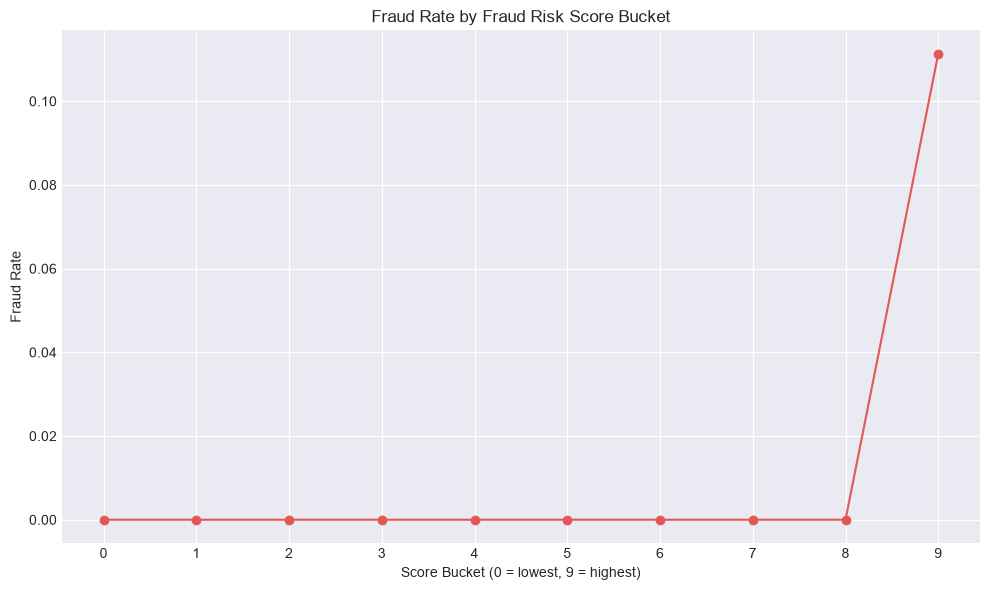

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(
    df_buckets["score_bucket"],
    df_buckets["fraud_rate"],
    marker="o",
    color="#E45756",
)
plt.xlabel("Score Bucket (0 = lowest, 9 = highest)")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Fraud Risk Score Bucket")
plt.xticks(df_buckets["score_bucket"])
plt.tight_layout()
plt.show()

In [9]:
top_tx = (
    df_tx_scores.sort_values("fraud_risk_score", ascending=False)
    .head(20)[
        ["transaction_id", "card_id", "timestamp", "amount",
         "merchant_segment", "channel", "country",
         "is_fraud", "any_rule_hit", "fraud_risk_score"]
    ]
)

top_tx

,transaction_id,card_id,timestamp,amount,merchant_segment,channel,country,is_fraud,any_rule_hit,fraud_risk_score
10284,T0050547,C001800,2026-01-10 04:53:31,11930.76,marketplace,card_not_present,CA,True,True,1.0
558,T0050442,C002102,2026-01-10 00:16:19,10407.55,electronics,card_not_present,CA,True,True,1.0
10831,T0050548,C002042,2026-01-10 05:10:12,10969.67,electronics,card_not_present,GB,True,True,1.0
1908,T0050559,C000688,2026-01-10 00:54:34,10845.79,travel,card_not_present,US,True,True,1.0
12553,T0050451,C001935,2026-01-10 05:58:55,10853.35,travel,card_not_present,FR,True,True,1.0
12578,T0050544,C001935,2026-01-10 05:59:21,11662.17,electronics,card_not_present,GB,True,True,1.0
7025,T0050516,C001730,2026-01-10 03:18:34,10764.63,travel,card_not_present,GB,True,True,1.0
3146,T0050471,C001095,2026-01-10 01:30:46,11726.18,marketplace,card_not_present,IN,True,True,1.0
6519,T0050550,C002480,2026-01-10 03:04:03,11407.49,electronics,card_not_present,IN,True,True,1.0
3159,T0050489,C000353,2026-01-10 01:31:08,11764.59,electronics,card_not_present,IN,True,True,1.0


### Transaction-Level Risk Interpretation

By looking at the top-scoring transactions:

- Most high-risk transactions combine features such as:
  - **Rule hits** (velocity or high amount),
  - Unusually large amounts,
  - Particular merchant segments or channels (e.g., card-not-present),
- and are labelled as synthetic fraud in this dataset.

In a real environment, this view would be used by fraud operations teams to:

- validate model behaviour,
- understand why a transaction was flagged (rules + model features),
- and refine thresholds or investigation queues.

In [10]:
card_kri_scores_path = Path("../outputs/fraud_card_kri_with_scores.csv")
df_card_scores = pd.read_csv(card_kri_scores_path)

df_card_scores[[
    "card_id",
    "tx_count",
    "fraud_tx",
    "any_rule_hits",
    "avg_fraud_score",
    "max_fraud_score",
    "status",
    "combined_status",
]].head(15)

,card_id,tx_count,fraud_tx,any_rule_hits,avg_fraud_score,max_fraud_score,status,combined_status
0,C000001,18,0,0,0.000083,0.000246,Low Risk,Low Risk
1,C000002,22,0,0,0.001031,0.003424,Low Risk,Low Risk
2,C000003,17,0,0,0.000069,0.000348,Low Risk,Low Risk
3,C000004,29,0,0,0.026704,0.093441,Low Risk,Low Risk
4,C000005,13,0,0,0.000013,0.000049,Low Risk,Low Risk
5,C000006,16,0,0,0.000052,0.000176,Low Risk,Low Risk
6,C000007,18,0,0,0.000115,0.000455,Low Risk,Low Risk
7,C000008,27,0,0,0.009341,0.055182,Low Risk,Low Risk
8,C000009,16,0,0,0.000035,0.000193,Low Risk,Low Risk
9,C000010,28,0,0,0.014711,0.056894,Low Risk,Low Risk


### Combined Rules + AI KRIs at Card Level

The card-level view now includes:

- **Rule-based indicators**: number of rule hits, rule-based status.
- **Model-based indicators**: average and maximum fraud risk score per card.
- **Combined status** that considers both rules and model output.

This supports a layered approach to fraud monitoring:

- Cards with **high scores and rule hits** move into the highest risk categories and should be prioritised for investigation or blocking.
- Cards with **high scores but no rule hits** might represent patterns the rules did not capture, suggesting where rules can be updated.
- Cards with **rule hits but low scores** may be false positives that could be de-prioritised or refined.

This kind of blended rules + AI KRI view is consistent with how modern fraud programmes combine deterministic controls and machine learning.

## Second-Line Fraud Risk Narrative

From a second-line ERM perspective, this AI-driven component adds:

- A **continuous fraud risk score** that complements binary rules and supports prioritisation.
- A set of **model performance metrics** (ROC-AUC, precision/recall, average precision) that can be monitored over time.
- **Feature importance** and score bucket analysis that make the model explainable and challengeable.

In governance and interview conversations, this module demonstrates:

- Familiarity with **AI-driven fraud detection** concepts.
- Ability to integrate AI outputs into a **KRI framework** alongside rules.
- Awareness of the trade-offs between detection performance, false positives, and operational workload.

## Limitations and Next Steps

**Limitations:**

- Data and labels are synthetic and tuned for illustration, not production.
- The model uses a relatively small feature set and does not capture all possible behavioural and contextual signals.
- Thresholds for high/medium scores are illustrative and would require calibration in real settings.

**Next Steps:**

- Expand feature engineering (e.g., time-of-day features, recent velocity features, more granular card history).
- Experiment with tree-based or ensemble models while maintaining explainability (e.g., using SHAP).
- Integrate model outputs into more detailed decision strategies (e.g., when to block vs step-up vs monitor).
- Embed the fraud risk score in a broader **ERM dashboard** across credit, liquidity, and fraud.